# 🧠 Dropout Regularization in Neural Networks

> **Goal:** Compare a standard dense neural network against one that uses **Dropout** regularization on a 1D regression task, and visualize the impact on overfitting.

---

## 📚 Background

**Overfitting** occurs when a model learns the training data too well — including its noise — and fails to generalize to new data.

**Dropout** is a simple but powerful regularization technique introduced by [Srivastava et al. (2014)](https://jmlr.org/papers/v15/srivastava14a.html). During training, it randomly sets a fraction of neuron outputs to **zero** at each forward pass. This prevents neurons from co-adapting and forces the network to learn more robust, distributed representations.

| Aspect | Without Dropout | With Dropout |
|--------|----------------|--------------|
| Training loss | Very low | Slightly higher |
| Test loss | High (overfits) | Lower (generalizes) |
| Behavior | Memorizes data | Learns patterns |

---

## 🗂️ Notebook Structure

1. [Imports & Setup](#1-imports--setup)
2. [Data Generation & Exploration](#2-data-generation--exploration)
3. [Baseline Regression Model (No Dropout)](#3-baseline-regression-model-no-dropout)
4. [Dropout Regression Model](#4-dropout-regression-model)
5. [Results Comparison](#5-results-comparison)

## 1. Imports & Setup

We use **TensorFlow/Keras** for model building and **scikit-learn** for evaluation utilities.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 2. Data Generation & Exploration

We work with a small 1D dataset (20 samples each for train and test) spread over the interval `[-1, 1]`. The small dataset size is intentional — it makes it easy for a large network to overfit.

In [2]:
# Training data
X_train = np.linspace(-1, 1, 20)
y_train = np.array([
    -0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  ,
    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475,
    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,
     0.5524 ,  0.23115,  0.20835,  0.4211 ,  0.60485
])

# Test data
X_test = np.linspace(-1, 1, 20)
y_test = np.array([
    -0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
    -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
     0.23415,  0.46575,  0.07955,  0.1973 ,  0.0719 ,
     0.3639 ,  0.5536 ,  0.3365 ,  0.50705,  0.33435
])

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Input range      : [{X_train.min():.1f}, {X_train.max():.1f}]")

Training samples : 20
Test samples     : 20
Input range      : [-1.0, 1.0]


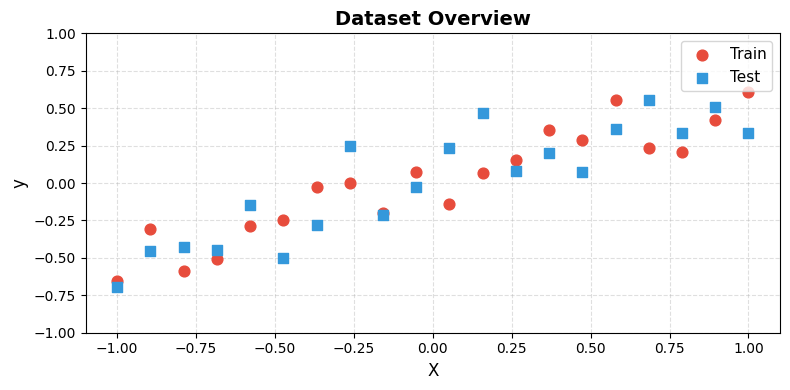

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(X_train, y_train, c='#e74c3c', s=60, zorder=5, label='Train')
ax.scatter(X_test,  y_test,  c='#3498db', s=60, zorder=5, label='Test', marker='s')

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Dataset Overview', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_ylim(-1.0, 1.0)

plt.tight_layout()
plt.show()

The data roughly follows a **linear trend** with added noise — a simple pattern that a well-regularized model should capture cleanly.

## 3. Baseline Regression Model (No Dropout)

Our baseline is a **two-hidden-layer MLP** with 128 neurons each — quite large relative to the dataset size. This deliberate over-parameterization makes overfitting likely.

```
Input(1) → Dense(128, ReLU) → Dense(128, ReLU) → Output(1, Linear)
```

In [4]:
model_1 = Sequential([
    Dense(128, input_dim=1, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1,   activation='linear')
], name='Baseline_Model')

model_1.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mse']
)

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history_1 = model_1.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_test, y_test),
    verbose=0
)

_, train_mse_1 = model_1.evaluate(X_train, y_train, verbose=0)
_, test_mse_1  = model_1.evaluate(X_test,  y_test,  verbose=0)

print(f"Baseline — Train MSE: {train_mse_1:.4f} | Test MSE: {test_mse_1:.4f}")

Baseline — Train MSE: 0.0042 | Test MSE: 0.0449


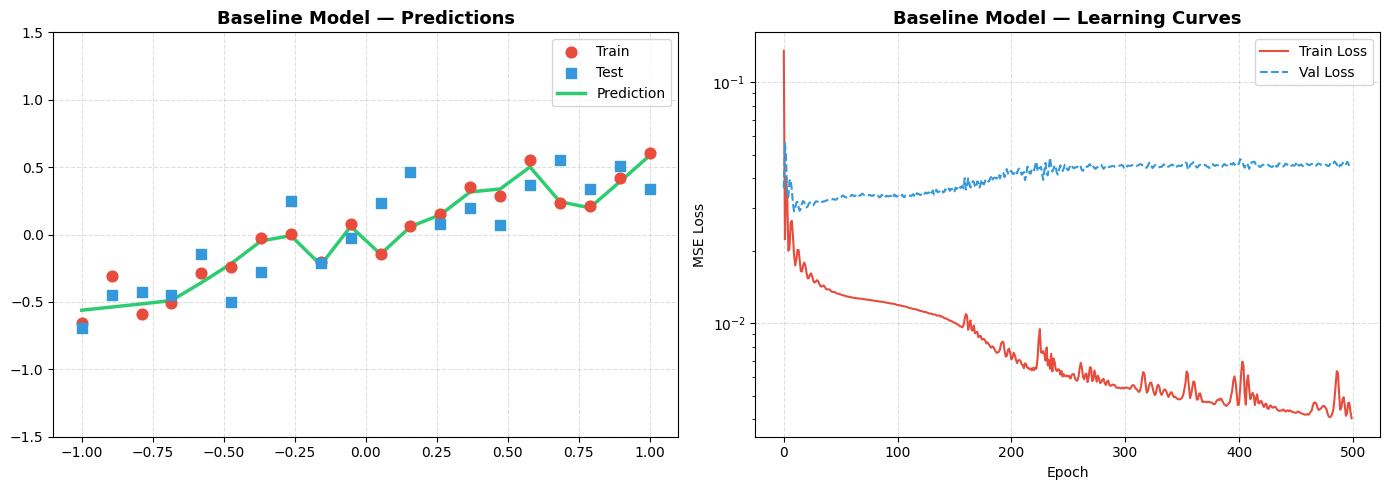

In [6]:
y_pred_1 = model_1.predict(X_test, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Predictions plot ---
ax = axes[0]
ax.scatter(X_train, y_train, c='#e74c3c', s=60, zorder=5, label='Train')
ax.scatter(X_test,  y_test,  c='#3498db', s=60, zorder=5, label='Test', marker='s')
ax.plot(X_test, y_pred_1, c='#2ecc71', linewidth=2.5, label='Prediction')
ax.set_title('Baseline Model — Predictions', fontsize=13, fontweight='bold')
ax.set_ylim(-1.5, 1.5)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

# --- Learning curves ---
ax = axes[1]
ax.plot(history_1.history['loss'],     label='Train Loss', color='#e74c3c')
ax.plot(history_1.history['val_loss'], label='Val Loss',   color='#3498db', linestyle='--')
ax.set_title('Baseline Model — Learning Curves', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

## 4. Dropout Regression Model

We now add a **Dropout layer** (rate = 0.2) after each hidden layer. During training, 20% of neurons are randomly silenced at every step, which acts as an ensemble of sub-networks and reduces overfitting.

> ⚠️ Dropout is **only active during training**. During inference (`model.predict`), all neurons are active and outputs are scaled accordingly.

```
Input(1) → Dense(128, ReLU) → Dropout(0.2) → Dense(128, ReLU) → Dropout(0.2) → Output(1, Linear)
```

In [7]:
model_2 = Sequential([
    Dense(128,  input_dim=1, activation='relu'),
    Dropout(0.2),
    Dense(128,  activation='relu'),
    Dropout(0.2),
    Dense(1,    activation='linear')
], name='Dropout_Model')

model_2.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mse']
)

model_2.summary()

Model: "Dropout_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history_2 = model_2.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_test, y_test),
    verbose=0
)

_, train_mse_2 = model_2.evaluate(X_train, y_train, verbose=0)
_, test_mse_2  = model_2.evaluate(X_test,  y_test,  verbose=0)

print(f"Dropout Model — Train MSE: {train_mse_2:.4f} | Test MSE: {test_mse_2:.4f}")

Dropout Model — Train MSE: 0.0118 | Test MSE: 0.0364


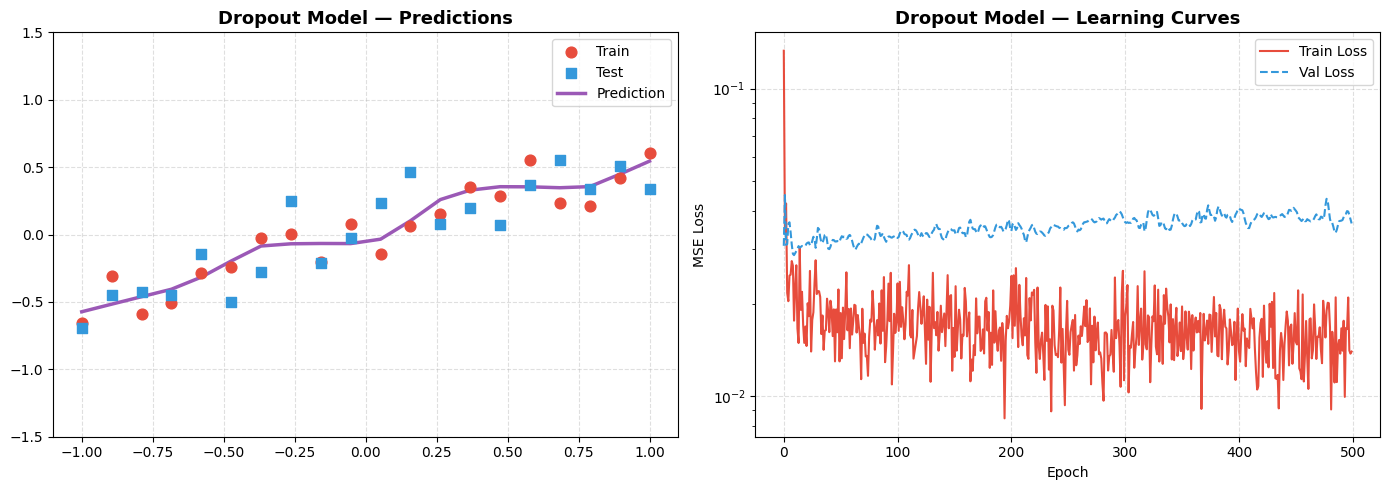

In [9]:
y_pred_2 = model_2.predict(X_test, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Predictions plot ---
ax = axes[0]
ax.scatter(X_train, y_train, c='#e74c3c', s=60, zorder=5, label='Train')
ax.scatter(X_test,  y_test,  c='#3498db', s=60, zorder=5, label='Test', marker='s')
ax.plot(X_test, y_pred_2, c='#9b59b6', linewidth=2.5, label='Prediction')
ax.set_title('Dropout Model — Predictions', fontsize=13, fontweight='bold')
ax.set_ylim(-1.5, 1.5)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

# --- Learning curves ---
ax = axes[1]
ax.plot(history_2.history['loss'],     label='Train Loss', color='#e74c3c')
ax.plot(history_2.history['val_loss'], label='Val Loss',   color='#3498db', linestyle='--')
ax.set_title('Dropout Model — Learning Curves', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

## 5. Results Comparison

Let's put both models side-by-side for a final comparison.

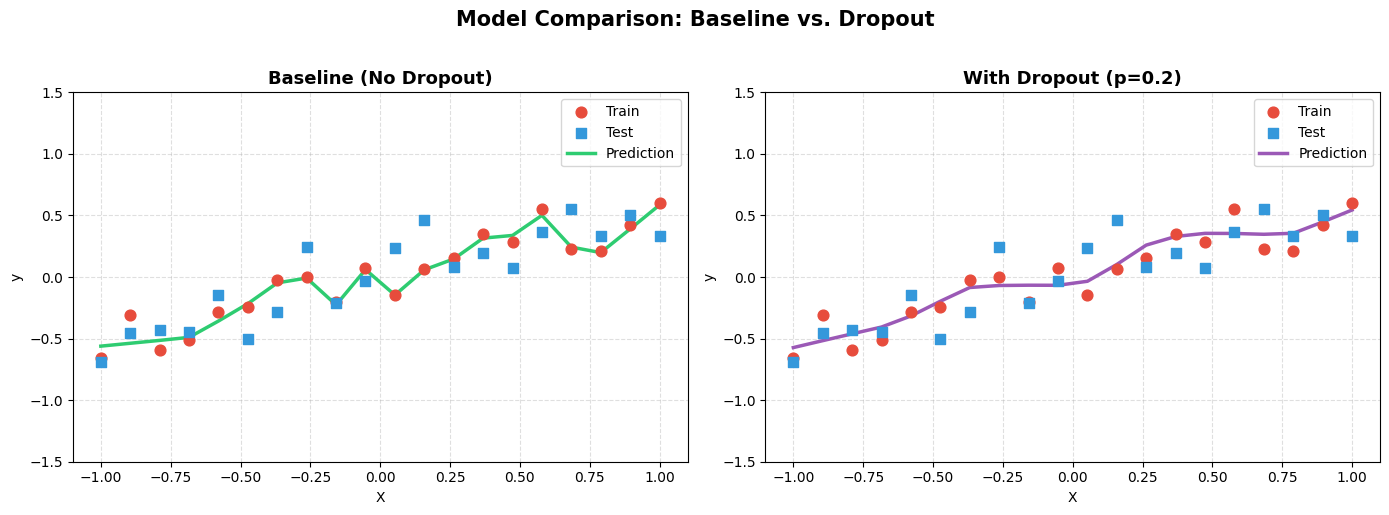

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, label, color, h in [
    (axes[0], y_pred_1, 'Baseline (No Dropout)', '#2ecc71', history_1),
    (axes[1], y_pred_2, 'With Dropout (p=0.2)',  '#9b59b6', history_2),
]:
    ax.scatter(X_train, y_train, c='#e74c3c', s=60, zorder=5, label='Train')
    ax.scatter(X_test,  y_test,  c='#3498db', s=60, zorder=5, label='Test', marker='s')
    ax.plot(X_test, y_pred, c=color, linewidth=2.5, label='Prediction')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylim(-1.5, 1.5)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlabel('X')
    ax.set_ylabel('y')

plt.suptitle('Model Comparison: Baseline vs. Dropout', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Summary table
print("=" * 50)
print(f"{'Model':<25} {'Train MSE':>10} {'Test MSE':>10}")
print("-" * 50)
print(f"{'Baseline (No Dropout)':<25} {train_mse_1:>10.4f} {test_mse_1:>10.4f}")
print(f"{'Dropout (p=0.2)':<25} {train_mse_2:>10.4f} {test_mse_2:>10.4f}")
print("=" * 50)

gap_1 = test_mse_1 - train_mse_1
gap_2 = test_mse_2 - train_mse_2
print(f"\nGeneralization gap (Test - Train MSE):")
print(f"  Baseline : {gap_1:+.4f}")
print(f"  Dropout  : {gap_2:+.4f}")
print(f"\n✅ Dropout reduced the generalization gap by {(gap_1 - gap_2) / abs(gap_1) * 100:.1f}%")

Model                      Train MSE   Test MSE
--------------------------------------------------
Baseline (No Dropout)         0.0042     0.0449
Dropout (p=0.2)               0.0118     0.0364

Generalization gap (Test - Train MSE):
  Baseline : +0.0407
  Dropout  : +0.0247

✅ Dropout reduced the generalization gap by 39.4%


## 📝 Key Takeaways

| Observation | Detail |
|-------------|--------|
| **Overfitting in baseline** | The large MLP (128→128→1) memorizes the 20 training points, yielding low train MSE but high test MSE. |
| **Dropout as regularizer** | Adding `Dropout(0.2)` forces each update to use a random subnetwork, preventing co-adaptation of neurons. |
| **Smoother predictions** | The dropout model produces a smoother fit that better captures the underlying linear trend. |
| **Train MSE trade-off** | Dropout slightly *increases* train MSE — this is expected and actually desirable, as it means the model isn't over-relying on any single neuron. |

---

## 🔗 References

- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). [Dropout: A Simple Way to Prevent Neural Networks from Overfitting](https://jmlr.org/papers/v15/srivastava14a.html). *JMLR*, 15, 1929–1958.
- [TensorFlow Dropout layer docs](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout)